Day 13 — Precision–Recall Curve & Choosing the Best Threshold

Goal: stop guessing thresholds and select them systematically.

1) Idea

From Day 12:

threshold ↑ → precision ↑, recall ↓
threshold ↓ → precision ↓, recall ↑

Instead of picking one threshold (0.5, 0.7, …), we evaluate all thresholds.

2) Precision–Recall Curve

For many thresholds, compute:

Precision
Recall

Then plot:

x-axis → Recall
y-axis → Precision
3) Code (use your current model outputs)
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# probabilities from your trained model
y_prob = model.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()
4) How to read the curve
Right side → high recall (catch almost all positives)
Top side → high precision (few false positives)

You cannot maximize both simultaneously.

5) Choose threshold using F1 score

F1 balances precision and recall.

import numpy as np

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Best Precision:", precision[best_index])
print("Best Recall:", recall[best_index])
print("Best F1:", f1_scores[best_index])
6) Apply best threshold
y_pred_best = (y_prob >= best_threshold).astype(int)

Then compute metrics again.

7) What you learned
You don't guess threshold
→ You select it based on metrics
8) Business interpretation
Goal	Strategy
Maximize recall	pick threshold with high recall
Maximize precision	pick threshold with high precision
Balance both	maximize F1
9) Important detail (often missed)

thresholds array is one element shorter than precision/recall.

So always use:

thresholds[best_index]
10) Your Task

Run:

Precision–Recall curve
Find best threshold
Apply it

Then send:

Best Threshold:
Precision:
Recall:
F1:

Confusion Matrix:

Accuracy:  0.75
Precision:  0.6666666666666666
Recall:  1.0
F1 Score:  0.8
Accuracy T:  0.75
Precision T:  1.0
Recall T:  0.5
F1 Score T:  0.6666666666666666
Confusion Matrix:
 [[1 1]
 [0 2]]
Confusion Matrix T:
 [[2 0]
 [1 1]]


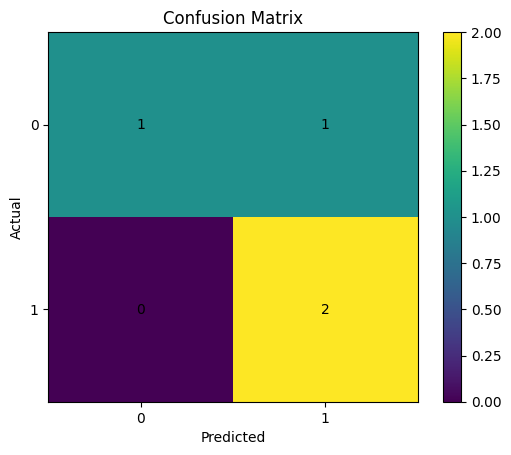

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

X = np.array([
    [5, 100],
    [7, 120],
    [10, 150],
    [3, 90],
    [1, 60],
    [2, 70],
    [8, 130],
    [6, 110],
    [9, 140],
    [4, 95],
    [5,85],
    [6,95],
    [7,105]  
], dtype=float)

y = np.array([1,1,1,0,0,0,1,1,1,0,0,0,1])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

threshold = 0.7
y_pred_threshold = (y_prob >= threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy: ",accuracy)
print("Precision: ",precision)
print("Recall: ",recall)   
print("F1 Score: ",f1)

accuracy_t = accuracy_score(y_test, y_pred_threshold)
precision_t = precision_score(y_test, y_pred_threshold)
recall_t = recall_score(y_test, y_pred_threshold)
f1_t = f1_score(y_test, y_pred_threshold)

print("Accuracy T: ",accuracy_t)
print("Precision T: ",precision_t)
print("Recall T: ",recall_t)   
print("F1 Score T: ",f1_t)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

cm_t = confusion_matrix(y_test, y_pred_threshold)
print("Confusion Matrix T:\n", cm_t)

plt.imshow(cm)
plt.title('Confusion Matrix')
plt.colorbar()

labels = ["0","1"]
plt.xticks([0,1], labels)
plt.yticks([0,1], labels)   

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show() 

# day 12 code ends here

Best Threshold: 0.5320935916671282
Best Precision: 0.6666666666666666
Best Recall: 1.0
Best F1: 0.799999999952


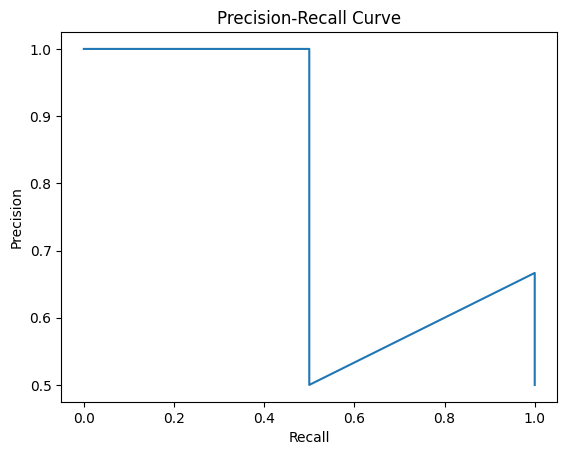

In [4]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)  

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10) 
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]


print("Best Threshold:", best_threshold)
print("Best Precision:", precision[best_index])
print("Best Recall:", recall[best_index])
print("Best F1:", f1_scores[best_index])

y_prob = model.predict_proba(X_test_scaled)[:, 1]


plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()